# §22 Drama Atlas — Analytics for Belief-Limited, High-Impact 42 Decisions

Framing: Gus's belief head is at the Bayes ceiling (§21, 39.2% top-1 = theoretically optimal).
The remaining 42-craft isn't about *knowing better* — it's about *acting well under unresolvable uncertainty*.
This notebook surfaces exactly where those decisions live in the 10k training corpus.

Three quantities per decision (from `q_per_world [M, 7]`):
1. **outcome_variance**: `q_per_world[:, action_taken].std()` — knife's-edge outcome
2. **action_fragility**: count distinct oracle-best actions across M worlds — fog-of-war
3. **belief_sharpness**: `1 − H(belief) / H_max` averaged over unseen dominoes — what Gus knows

**Drama** = high fragility + high outcome_variance + low belief_sharpness.

In [1]:
import sys
sys.path.insert(0, '/Users/jason/code/mk5-main')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import json
from pathlib import Path

# Consistent style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ATLAS_PATH = Path('/Users/jason/code/mk5-main/gus/analysis/drama_atlas.parquet')
FIGURES_DIR = Path('/Users/jason/code/mk5-main/gus/analysis/figures')
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(ATLAS_PATH)
print(f'Loaded {len(df):,} decisions ({df["split"].value_counts().to_dict()})')
df.head(3)

Loaded 280,560 decisions ({'train': 280000, 'eval': 560})


,split,seed,game_idx,d_idx,current_player,decl_id,outcome_variance,action_fragility,belief_sharpness,p_make_taken,...,gus_matches_mode,action_taken,n_legal_actions,e_q_taken,e_q_max,per_world_top_action_distribution,quadrant,drama_score,trick_num,trick_pos
0,eval,900000,0,0,0,0,23.276617,7,0.011911,0.31675,...,1,0,7,-11.149720,-11.149720,"{""0"": 2383, ""1"": 481, ""2"": 258, ""3"": 169, ""4"":...",drama,3.829319,0,0
1,eval,900000,0,1,1,0,20.472525,7,0.016432,0.77775,...,1,1,7,16.676029,16.689590,"{""0"": 1915, ""1"": 1138, ""2"": 113, ""3"": 30, ""4"":...",drama,3.489024,0,1
2,eval,900000,0,2,2,0,20.052561,2,0.009958,0.14525,...,1,2,2,-22.569584,-22.569584,"{""0"": 773, ""2"": 3227}",foggy-forced,0.750633,0,2


## 1. Summary Statistics

In [2]:
cols = ['outcome_variance', 'action_fragility', 'belief_sharpness', 'p_make_taken', 'gus_matches_mode']

summary = df.groupby('split')[cols].agg(['mean', 'median', lambda x: x.quantile(0.99)]).round(4)
summary.columns = ['_'.join(c) for c in summary.columns]
print('=== Summary by split ===')
print(summary.T.to_string())
print()

# Save summary
TABLES_DIR = Path('/Users/jason/code/mk5-main/gus/analysis/tables')
TABLES_DIR.mkdir(exist_ok=True)
summary.to_csv(TABLES_DIR / 'drama_summary_by_split.csv')
print('Saved: tables/drama_summary_by_split.csv')

=== Summary by split ===
split                           eval    train
outcome_variance_mean        13.3702  13.1414
outcome_variance_median      14.8415  14.4040
outcome_variance_<lambda_0>  28.5336  29.0578
action_fragility_mean         2.6071   2.5899
action_fragility_median       2.0000   2.0000
action_fragility_<lambda_0>   7.0000   7.0000
belief_sharpness_mean         0.0640   0.0638
belief_sharpness_median       0.0199   0.0201
belief_sharpness_<lambda_0>   1.0000   1.0000
p_make_taken_mean             0.5056   0.5046
p_make_taken_median           0.4848   0.4785
p_make_taken_<lambda_0>       1.0000   1.0000
gus_matches_mode_mean         0.7607   0.7241
gus_matches_mode_median       1.0000   1.0000
gus_matches_mode_<lambda_0>   1.0000   1.0000

Saved: tables/drama_summary_by_split.csv


In [3]:
# Full split summary for the paper
print('=== Full corpus summary (all splits) ===')
full_summary = df[cols].agg(['mean', 'std', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), lambda x: x.quantile(0.99)])
full_summary.index = ['mean', 'std', 'median', 'p25', 'p75', 'p99']
print(full_summary.round(4).to_string())

print(f"\nGus-matches-mode (all): {df['gus_matches_mode'].mean():.3%}")
print(f"Fragility distribution:")
print(df['action_fragility'].value_counts().sort_index())

=== Full corpus summary (all splits) ===
        outcome_variance  action_fragility  belief_sharpness  p_make_taken  gus_matches_mode
mean             13.1418            2.5899            0.0638        0.5046            0.7241
std               8.8853            1.8338            0.1828        0.3428            0.4470
median           14.4055            2.0000            0.0201        0.4785            1.0000
p25               5.2121            1.0000            0.0129        0.2227            0.0000
p75              20.3947            4.0000            0.0344        0.8315            1.0000
p99              29.0578            7.0000            1.0000        1.0000            1.0000

Gus-matches-mode (all): 72.413%
Fragility distribution:
action_fragility
1    113140
2     59742
3     32587
4     23576
5     20590
6     17485
7     13440
Name: count, dtype: int64


## 2. The Hero Figure: 3D Drama Space

Each decision is a point in (belief_sharpness, action_fragility, outcome_variance) space.
The drama quadrant is bottom-left (low sharpness) + high fragility + high variance.

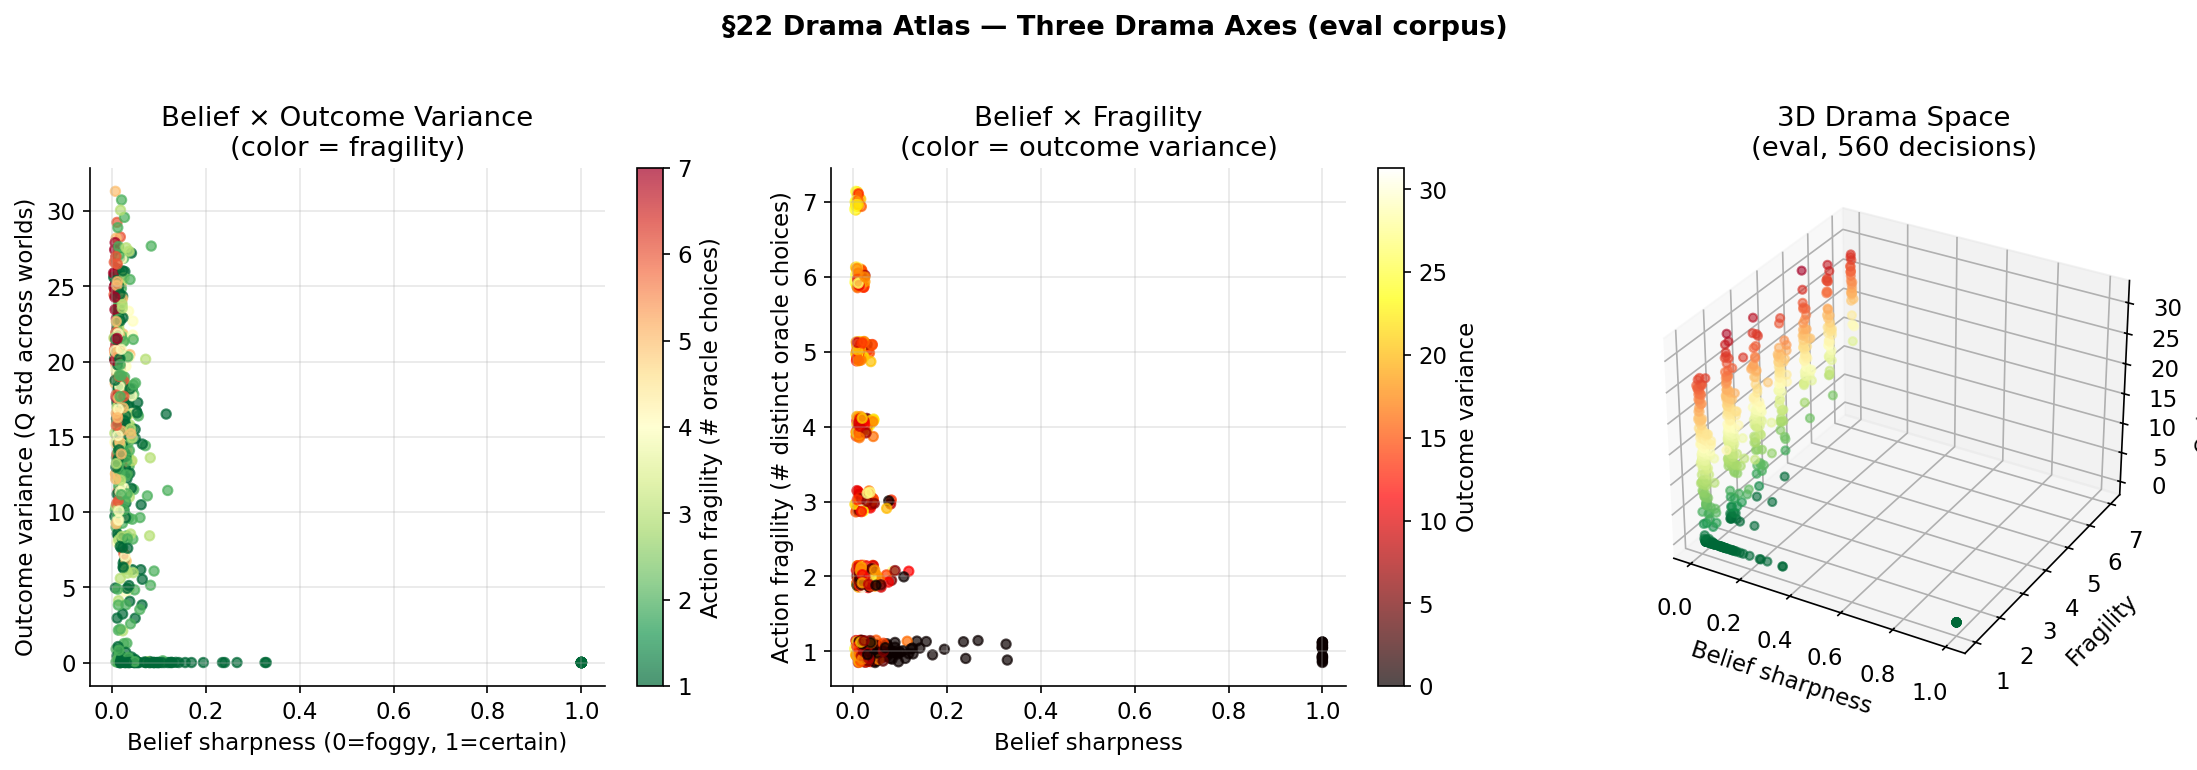

Saved: figures/drama_hero_scatter.png


In [4]:
# Use eval split for the hero figure (fully visualizable; 560 decisions)
ev = df[df['split'] == 'eval'].copy()
tr = df[df['split'] == 'train'].copy()

fig = plt.figure(figsize=(15, 5))

# --- Left: 2D scatter belief_sharpness vs outcome_variance, colored by action_fragility
ax1 = fig.add_subplot(131)
scatter1 = ax1.scatter(
    ev['belief_sharpness'], ev['outcome_variance'],
    c=ev['action_fragility'], cmap='RdYlGn_r', s=20, alpha=0.7, vmin=1, vmax=7
)
plt.colorbar(scatter1, ax=ax1, label='Action fragility (# oracle choices)')
ax1.set_xlabel('Belief sharpness (0=foggy, 1=certain)')
ax1.set_ylabel('Outcome variance (Q std across worlds)')
ax1.set_title('Belief × Outcome Variance\n(color = fragility)')

# --- Middle: 2D scatter belief_sharpness vs action_fragility, colored by outcome_variance
ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(
    ev['belief_sharpness'], ev['action_fragility'] + np.random.uniform(-0.15, 0.15, len(ev)),
    c=ev['outcome_variance'], cmap='hot', s=20, alpha=0.7
)
plt.colorbar(scatter2, ax=ax2, label='Outcome variance')
ax2.set_xlabel('Belief sharpness')
ax2.set_ylabel('Action fragility (# distinct oracle choices)')
ax2.set_title('Belief × Fragility\n(color = outcome variance)')

# --- Right: 3D
ax3 = fig.add_subplot(133, projection='3d')
sc = ax3.scatter(
    ev['belief_sharpness'], ev['action_fragility'], ev['outcome_variance'],
    c=ev['outcome_variance'], cmap='RdYlGn_r', s=15, alpha=0.6
)
ax3.set_xlabel('Belief sharpness')
ax3.set_ylabel('Fragility')
ax3.set_zlabel('Outcome var')
ax3.set_title('3D Drama Space\n(eval, 560 decisions)')

fig.suptitle('§22 Drama Atlas — Three Drama Axes (eval corpus)', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'drama_hero_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/drama_hero_scatter.png')

## 3. Quadrant Analysis

Defining 4 quadrants based on **action_fragility** and **belief_sharpness**:

| | **Sharp belief** (sharpness ≥ median) | **Foggy belief** (sharpness < median) |
|---|---|---|
| **Low fragility** (≤ 1) | Easy-robust: oracle agrees, Gus knows why | Easy-forced: oracle agrees but Gus is guessing |
| **High fragility** (≥ 3) | High-stakes: oracle disagrees but Gus has signal | **DRAMA**: oracle disagrees AND Gus is in the dark |

Thresholds: fragility ≥ 3 (3+ distinct oracle recommendations = genuine fog), belief_sharpness < median.

In [5]:
# Compute thresholds on train (to avoid circularity with eval)
SHARPNESS_THRESH = tr['belief_sharpness'].median()
FRAGILITY_THRESH = 3  # 3+ distinct oracle actions = genuine fog
VARIANCE_THRESH = tr['outcome_variance'].median()

print(f'Thresholds (from train):')
print(f'  belief_sharpness median: {SHARPNESS_THRESH:.4f}')
print(f'  action_fragility threshold: {FRAGILITY_THRESH}')
print(f'  outcome_variance median: {VARIANCE_THRESH:.4f}')

def assign_quadrant(row):
    sharp = row['belief_sharpness'] >= SHARPNESS_THRESH
    fragile = row['action_fragility'] >= FRAGILITY_THRESH
    if not fragile and sharp:
        return 'easy-robust'
    elif not fragile and not sharp:
        return 'foggy-forced'
    elif fragile and sharp:
        return 'easy-high-stakes'
    else:  # fragile + foggy
        return 'drama'

df['quadrant'] = df.apply(assign_quadrant, axis=1)

print('\n=== Quadrant counts (full corpus) ===')
qc = df['quadrant'].value_counts()
print(qc)
print(f'\nDrama fraction: {(df["quadrant"]=="drama").mean():.3%}')

print('\n=== Quadrant counts by split ===')
print(df.groupby('split')['quadrant'].value_counts(normalize=True).round(4))

Thresholds (from train):
  belief_sharpness median: 0.0201
  action_fragility threshold: 3
  outcome_variance median: 14.4040



=== Quadrant counts (full corpus) ===
quadrant
easy-robust         106155
drama                73557
foggy-forced         66727
easy-high-stakes     34121
Name: count, dtype: int64

Drama fraction: 26.218%

=== Quadrant counts by split ===
split  quadrant        
eval   easy-robust         0.3714
       drama               0.2607
       foggy-forced        0.2464
       easy-high-stakes    0.1214
train  easy-robust         0.3784
       drama               0.2622
       foggy-forced        0.2378
       easy-high-stakes    0.1216
Name: proportion, dtype: float64


In [6]:
# Save quadrant table
quad_summary = df.groupby(['split', 'quadrant']).agg(
    n=('d_idx', 'count'),
    mean_outcome_var=('outcome_variance', 'mean'),
    mean_fragility=('action_fragility', 'mean'),
    mean_sharpness=('belief_sharpness', 'mean'),
    gus_matches_mode=('gus_matches_mode', 'mean'),
).round(4)
quad_summary.to_csv(TABLES_DIR / 'quadrant_summary.csv')
print(quad_summary.to_string())

                             n  mean_outcome_var  mean_fragility  mean_sharpness  gus_matches_mode
split quadrant                                                                                    
eval  drama                146           18.2903          4.9521          0.0117            0.5685
      easy-high-stakes      68           15.2992          3.8529          0.0331            0.5735
      easy-robust          208            8.4513          1.3077          0.1442            0.8942
      foggy-forced         138           14.6282          1.4710          0.0138            0.8551
train drama              73411           18.2409          4.8776          0.0119            0.5258
      easy-high-stakes   34053           14.2274          3.9629          0.0304            0.4650
      easy-robust       105947            7.5944          1.2860          0.1419            0.8654
      foggy-forced       66589           15.7896          1.4402          0.0138            0.8502


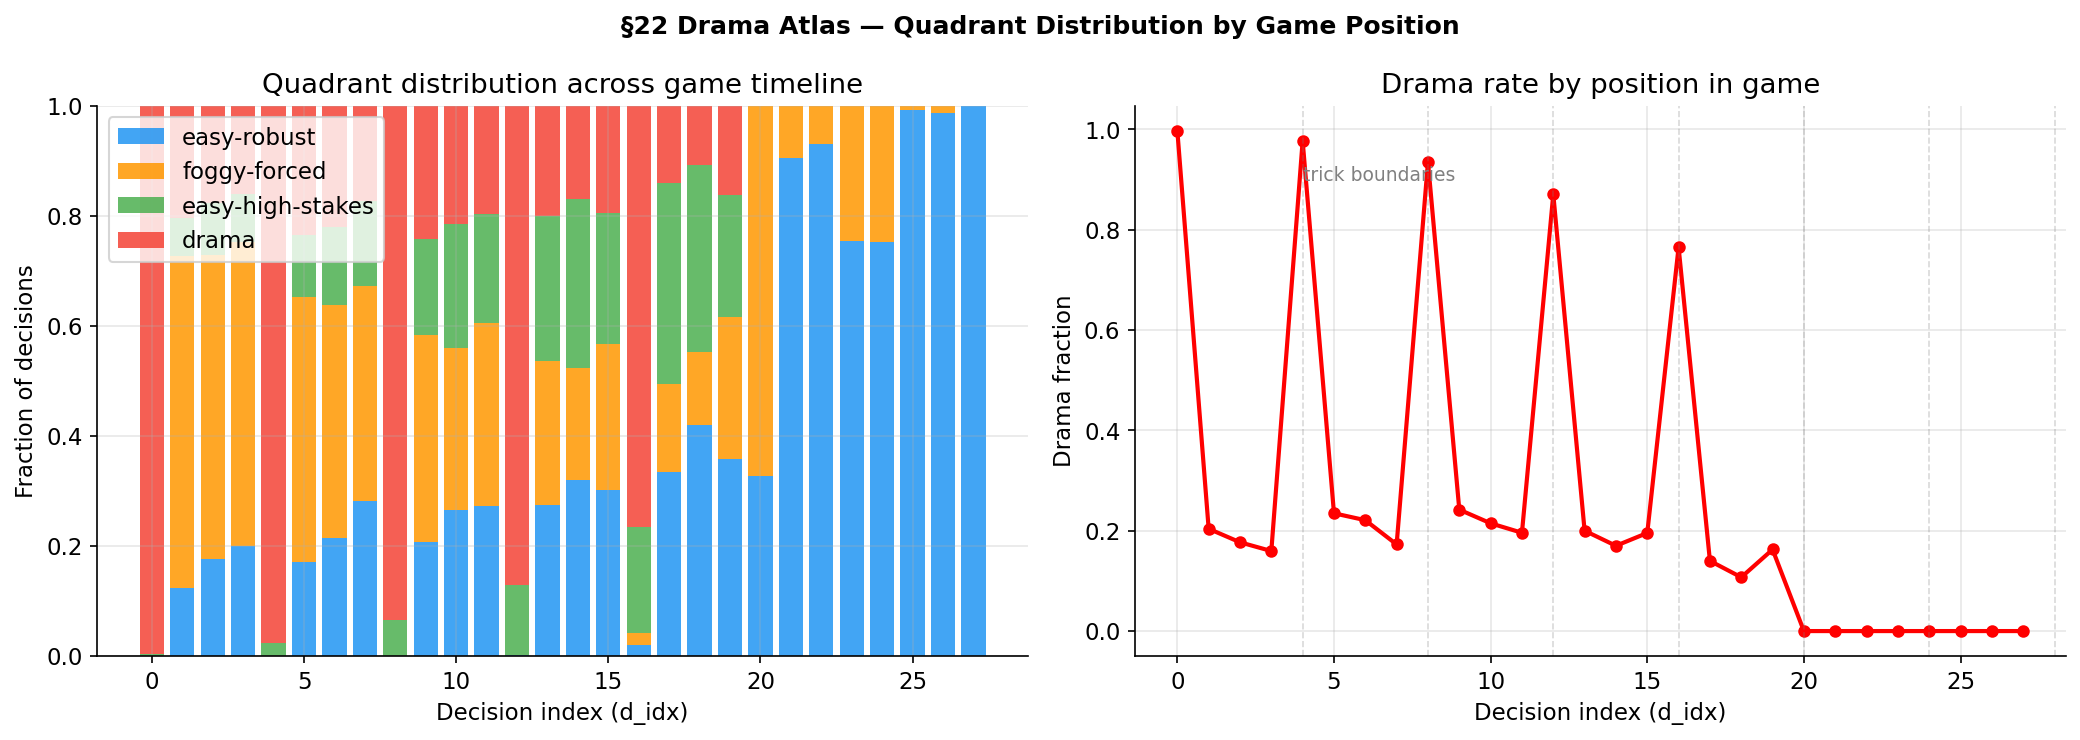

Saved: figures/drama_quadrant_by_didx.png


In [7]:
# Quadrant distribution by d_idx — where does drama concentrate?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COLORS = {'easy-robust': '#2196F3', 'foggy-forced': '#FF9800',
          'easy-high-stakes': '#4CAF50', 'drama': '#F44336'}

# Left: stacked histogram by d_idx
ax = axes[0]
quad_by_didx = df.groupby(['d_idx', 'quadrant']).size().unstack(fill_value=0)
# Normalize to fraction
quad_frac = quad_by_didx.div(quad_by_didx.sum(axis=1), axis=0)

ordered_quads = ['easy-robust', 'foggy-forced', 'easy-high-stakes', 'drama']
bottom = np.zeros(len(quad_frac))
for q in ordered_quads:
    if q in quad_frac.columns:
        vals = quad_frac[q].values
        ax.bar(quad_frac.index, vals, bottom=bottom, color=COLORS[q], label=q, alpha=0.85)
        bottom += vals

ax.set_xlabel('Decision index (d_idx)')
ax.set_ylabel('Fraction of decisions')
ax.set_title('Quadrant distribution across game timeline')
ax.legend(loc='upper left')

# Right: drama fraction by d_idx
ax2 = axes[1]
drama_by_didx = (df.groupby('d_idx')['quadrant'].apply(lambda x: (x=='drama').mean())).reset_index()
drama_by_didx.columns = ['d_idx', 'drama_fraction']
ax2.plot(drama_by_didx['d_idx'], drama_by_didx['drama_fraction'], 'r-o', markersize=5, linewidth=2)
ax2.set_xlabel('Decision index (d_idx)')
ax2.set_ylabel('Drama fraction')
ax2.set_title('Drama rate by position in game')
# Add trick boundaries (every 4 decisions = 1 trick, 4 players)
for trick in range(1, 8):
    ax2.axvline(trick*4, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
ax2.annotate('trick boundaries', (4, drama_by_didx['drama_fraction'].max()*0.9),
             fontsize=9, color='gray')

fig.suptitle('§22 Drama Atlas — Quadrant Distribution by Game Position', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'drama_quadrant_by_didx.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/drama_quadrant_by_didx.png')

## 4. Trick Position Deep-Dive

In Texas 42, players take turns in order around the table. d_idx 0-27 = 28 decisions (4 players × 7 tricks).
Trick position within each round = `d_idx % 4` (0=lead, 1=2nd, 2=3rd, 3=4th).
Trick number = `d_idx // 4` (0-6).

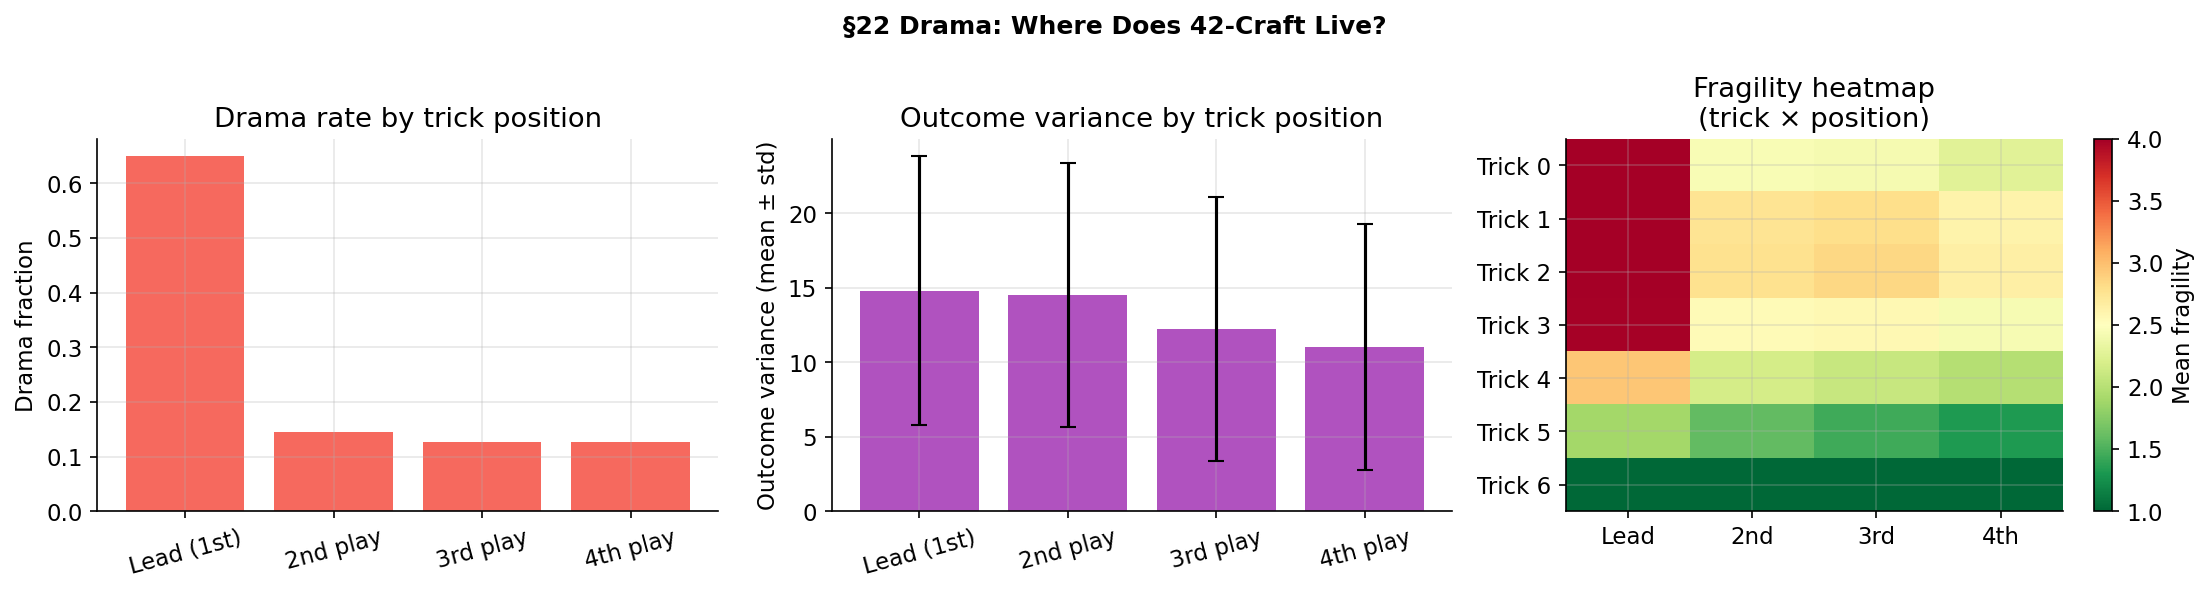

Saved: figures/drama_trick_position.png


In [8]:
df['trick_num'] = df['d_idx'] // 4
df['trick_pos'] = df['d_idx'] % 4

# Drama by trick position (lead, 2nd, 3rd, 4th)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pos_labels = ['Lead (1st)', '2nd play', '3rd play', '4th play']

# Drama by trick_pos
ax = axes[0]
drama_by_pos = df.groupby('trick_pos')['quadrant'].apply(lambda x: (x=='drama').mean())
ax.bar(range(4), drama_by_pos.values, color='#F44336', alpha=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels(pos_labels, rotation=15)
ax.set_ylabel('Drama fraction')
ax.set_title('Drama rate by trick position')

# Outcome variance by trick_pos
ax = axes[1]
var_by_pos = df.groupby('trick_pos')['outcome_variance'].agg(['mean', 'std'])
ax.bar(range(4), var_by_pos['mean'].values, yerr=var_by_pos['std'].values,
       color='#9C27B0', alpha=0.8, capsize=4)
ax.set_xticks(range(4))
ax.set_xticklabels(pos_labels, rotation=15)
ax.set_ylabel('Outcome variance (mean ± std)')
ax.set_title('Outcome variance by trick position')

# Action fragility by trick position and trick number (heatmap)
ax = axes[2]
frag_pivot = df.groupby(['trick_num', 'trick_pos'])['action_fragility'].mean().unstack()
im = ax.imshow(frag_pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=1, vmax=4)
plt.colorbar(im, ax=ax, label='Mean fragility')
ax.set_xticks(range(4))
ax.set_xticklabels(['Lead', '2nd', '3rd', '4th'])
ax.set_yticks(range(7))
ax.set_yticklabels([f'Trick {t}' for t in range(7)])
ax.set_title('Fragility heatmap\n(trick × position)')

fig.suptitle('§22 Drama: Where Does 42-Craft Live?', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'drama_trick_position.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/drama_trick_position.png')

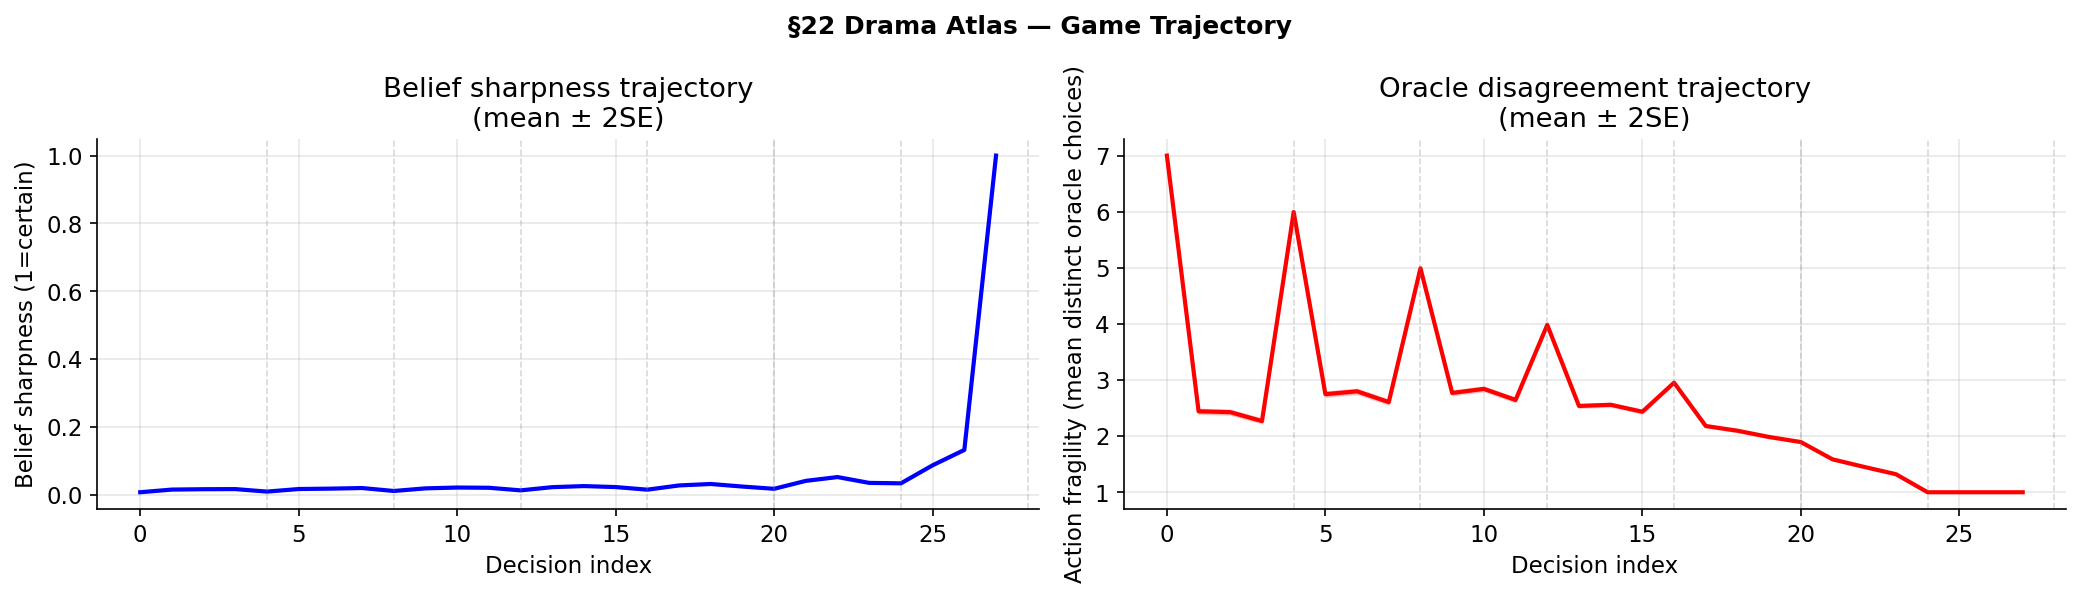

Saved: figures/drama_trajectory.png


In [9]:
# Belief sharpness trajectory — how certainty evolves over the game
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
sharp_by_didx = df.groupby('d_idx')['belief_sharpness'].agg(['mean', 'sem'])
ax.plot(sharp_by_didx.index, sharp_by_didx['mean'], 'b-', linewidth=2)
ax.fill_between(sharp_by_didx.index,
                sharp_by_didx['mean'] - 2*sharp_by_didx['sem'],
                sharp_by_didx['mean'] + 2*sharp_by_didx['sem'],
                alpha=0.2, color='blue')
ax.set_xlabel('Decision index')
ax.set_ylabel('Belief sharpness (1=certain)')
ax.set_title('Belief sharpness trajectory\n(mean ± 2SE)')
for trick in range(1, 8):
    ax.axvline(trick*4, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

ax = axes[1]
frag_by_didx = df.groupby('d_idx')['action_fragility'].agg(['mean', 'sem'])
ax.plot(frag_by_didx.index, frag_by_didx['mean'], 'r-', linewidth=2)
ax.fill_between(frag_by_didx.index,
                frag_by_didx['mean'] - 2*frag_by_didx['sem'],
                frag_by_didx['mean'] + 2*frag_by_didx['sem'],
                alpha=0.2, color='red')
ax.set_xlabel('Decision index')
ax.set_ylabel('Action fragility (mean distinct oracle choices)')
ax.set_title('Oracle disagreement trajectory\n(mean ± 2SE)')
for trick in range(1, 8):
    ax.axvline(trick*4, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

fig.suptitle('§22 Drama Atlas — Game Trajectory', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'drama_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/drama_trajectory.png')

## 5. Gus Behavior on Drama Decisions

The key §22 question: does Gus play the oracle mode, or something else?
On drama decisions (fragile + foggy), does Gus pick the marginal-mean-best action, or does it deviate?

In [10]:
# Gus agreement with mode action across quadrants
mode_by_quad = df.groupby('quadrant')['gus_matches_mode'].agg(['mean', 'count'])
mode_by_quad.columns = ['gus_matches_mode_rate', 'n']
print('=== Gus agreement with oracle mode (argmax marginal E[Q]) by quadrant ===')
print(mode_by_quad.sort_values('gus_matches_mode_rate', ascending=False).to_string())

print(f'\nOverall Gus-mode agreement: {df["gus_matches_mode"].mean():.3%}')
drama_mask = df['quadrant'] == 'drama'
print(f'Drama quadrant Gus-mode agreement: {df.loc[drama_mask, "gus_matches_mode"].mean():.3%}')
print(f'Easy-robust Gus-mode agreement: {df.loc[df["quadrant"]=="easy-robust", "gus_matches_mode"].mean():.3%}')

=== Gus agreement with oracle mode (argmax marginal E[Q]) by quadrant ===
                  gus_matches_mode_rate       n
quadrant                                       
easy-robust                    0.865451  106155
foggy-forced                   0.850166   66727
drama                          0.525932   73557
easy-high-stakes               0.465227   34121

Overall Gus-mode agreement: 72.413%
Drama quadrant Gus-mode agreement: 52.593%
Easy-robust Gus-mode agreement: 86.545%


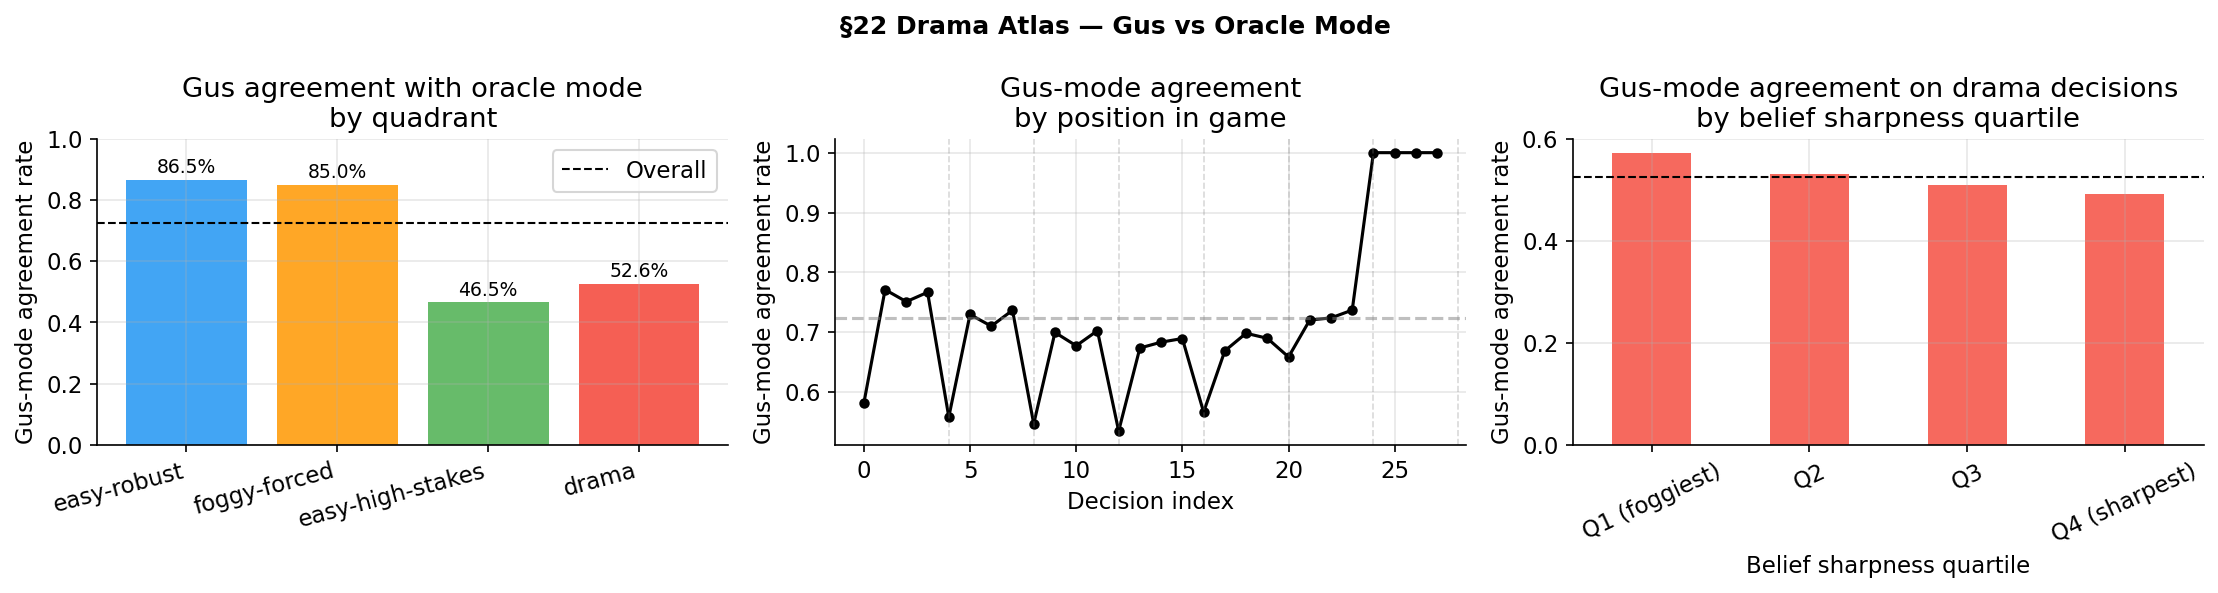

Saved: figures/drama_gus_vs_mode.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Left: Gus-mode agreement by quadrant (bar chart)
ax = axes[0]
quads = ['easy-robust', 'foggy-forced', 'easy-high-stakes', 'drama']
rates = [df[df['quadrant']==q]['gus_matches_mode'].mean() for q in quads]
colors = [COLORS[q] for q in quads]
bars = ax.bar(range(4), rates, color=colors, alpha=0.85)
ax.set_xticks(range(4))
ax.set_xticklabels(quads, rotation=15, ha='right')
ax.set_ylabel('Gus-mode agreement rate')
ax.set_ylim(0, 1)
ax.axhline(df['gus_matches_mode'].mean(), color='black', linestyle='--', linewidth=1, label='Overall')
ax.legend()
ax.set_title('Gus agreement with oracle mode\nby quadrant')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=9)

# --- Middle: Gus-mode agreement by d_idx
ax = axes[1]
gus_mode_by_didx = df.groupby('d_idx')['gus_matches_mode'].mean()
ax.plot(gus_mode_by_didx.index, gus_mode_by_didx.values, 'ko-', markersize=4, linewidth=1.5)
ax.axhline(df['gus_matches_mode'].mean(), color='gray', linestyle='--', alpha=0.5)
for trick in range(1, 8):
    ax.axvline(trick*4, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_xlabel('Decision index')
ax.set_ylabel('Gus-mode agreement rate')
ax.set_title('Gus-mode agreement\nby position in game')

# --- Right: cross-tab on drama decisions: Gus action vs mode action
ax = axes[2]
drama_df = df[drama_mask]
# For drama decisions, how often does Gus deviate? What fraction pick each fragility level?
# Show gus_matches_mode by belief_sharpness quantile
drama_df = drama_df.copy()
drama_df['sharpness_q'] = pd.qcut(drama_df['belief_sharpness'], q=4, labels=['Q1 (foggiest)', 'Q2', 'Q3', 'Q4 (sharpest)'])
gus_by_sharpness_q = drama_df.groupby('sharpness_q', observed=True)['gus_matches_mode'].mean()
gus_by_sharpness_q.plot(kind='bar', ax=ax, color='#F44336', alpha=0.8)
ax.set_ylabel('Gus-mode agreement rate')
ax.set_title('Gus-mode agreement on drama decisions\nby belief sharpness quartile')
ax.set_xlabel('Belief sharpness quartile')
ax.tick_params(axis='x', rotation=25)
ax.axhline(drama_df['gus_matches_mode'].mean(), color='black', linestyle='--', linewidth=1)

fig.suptitle('§22 Drama Atlas — Gus vs Oracle Mode', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'drama_gus_vs_mode.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/drama_gus_vs_mode.png')

## 6. Top-N Drama Decisions

Composite drama score: standardize each axis and sum with signs:
- `drama_score = Z(outcome_variance) + Z(action_fragility) - Z(belief_sharpness)`

High drama_score = high outcome variance + high fragility + low sharpness.

In [12]:
# Compute drama_score using train statistics for standardization
ov_mean = tr['outcome_variance'].mean()
ov_std = tr['outcome_variance'].std()
af_mean = tr['action_fragility'].mean()
af_std = tr['action_fragility'].std()
bs_mean = tr['belief_sharpness'].mean()
bs_std = tr['belief_sharpness'].std()

df['drama_score'] = (
    (df['outcome_variance'] - ov_mean) / ov_std
    + (df['action_fragility'] - af_mean) / af_std
    - (df['belief_sharpness'] - bs_mean) / bs_std
)

print('Drama score statistics:')
print(df['drama_score'].describe().round(3))

# Top 20 drama decisions from eval split (fully context-complete)
top_drama = df[df['split'] == 'eval'].nlargest(20, 'drama_score')

print('\n=== Top 20 drama decisions (eval split) ===')
display_cols = ['seed', 'd_idx', 'current_player', 'decl_id',
                'drama_score', 'outcome_variance', 'action_fragility',
                'belief_sharpness', 'action_taken', 'gus_pi_action',
                'mode_action', 'gus_matches_mode', 'e_q_taken', 'e_q_max',
                'per_world_top_action_distribution']
print(top_drama[display_cols].round(4).to_string())

# Save
top_drama[display_cols].to_csv(TABLES_DIR / 'top20_drama_eval.csv', index=False)
print('\nSaved: tables/top20_drama_eval.csv')

Drama score statistics:
count    280560.000
mean          0.000
std           2.239
min          -7.467
25%          -1.145
50%           0.169
75%           1.318
max           4.947
Name: drama_score, dtype: float64

=== Top 20 drama decisions (eval split) ===
       seed  d_idx  current_player  decl_id  drama_score  outcome_variance  action_fragility  belief_sharpness  action_taken  gus_pi_action  mode_action  gus_matches_mode  e_q_taken  e_q_max                                        per_world_top_action_distribution
448  900016      0               0        6       4.3775           27.9016                 7            0.0068             6              0            0                 1   -10.7650  -6.4294   {"0": 1321, "1": 980, "2": 425, "3": 502, "4": 108, "5": 19, "6": 645}
364  900013      0               0        3       4.3309           27.4331                 7            0.0057             4              1            4                 0    -2.0240  -2.0240     {"0": 56, "1":

In [13]:
# Top 20 drama decisions from train split (larger pool)
top_drama_train = df[df['split'] == 'train'].nlargest(20, 'drama_score')
display_cols2 = ['seed', 'game_idx', 'd_idx', 'current_player', 'decl_id',
                 'drama_score', 'outcome_variance', 'action_fragility',
                 'belief_sharpness', 'action_taken', 'gus_pi_action',
                 'mode_action', 'gus_matches_mode', 'e_q_taken', 'e_q_max']
print('=== Top 20 drama decisions (train split) ===')
print(top_drama_train[display_cols2].round(4).to_string())
top_drama_train[display_cols2].to_csv(TABLES_DIR / 'top20_drama_train.csv', index=False)
print('\nSaved: tables/top20_drama_train.csv')

=== Top 20 drama decisions (train split) ===
        seed  game_idx  d_idx  current_player  decl_id  drama_score  outcome_variance  action_fragility  belief_sharpness  action_taken  gus_pi_action  mode_action  gus_matches_mode  e_q_taken  e_q_max
211093  7719      7519      1               1        9       4.9469           33.9579                 7            0.0274             2              0            1                 0     4.1204   4.1385
217980  7965      7765      0               0        5       4.9117           32.5876                 7            0.0056             2              0            0                 1   -10.4658  -4.5314
102621  4145      3645      1               1        5       4.8599           33.0144                 7            0.0239             2              5            6                 0    -8.0105  -6.7275
238140  8585      8485      0               0        5       4.8490           32.0643                 7            0.0063             5            

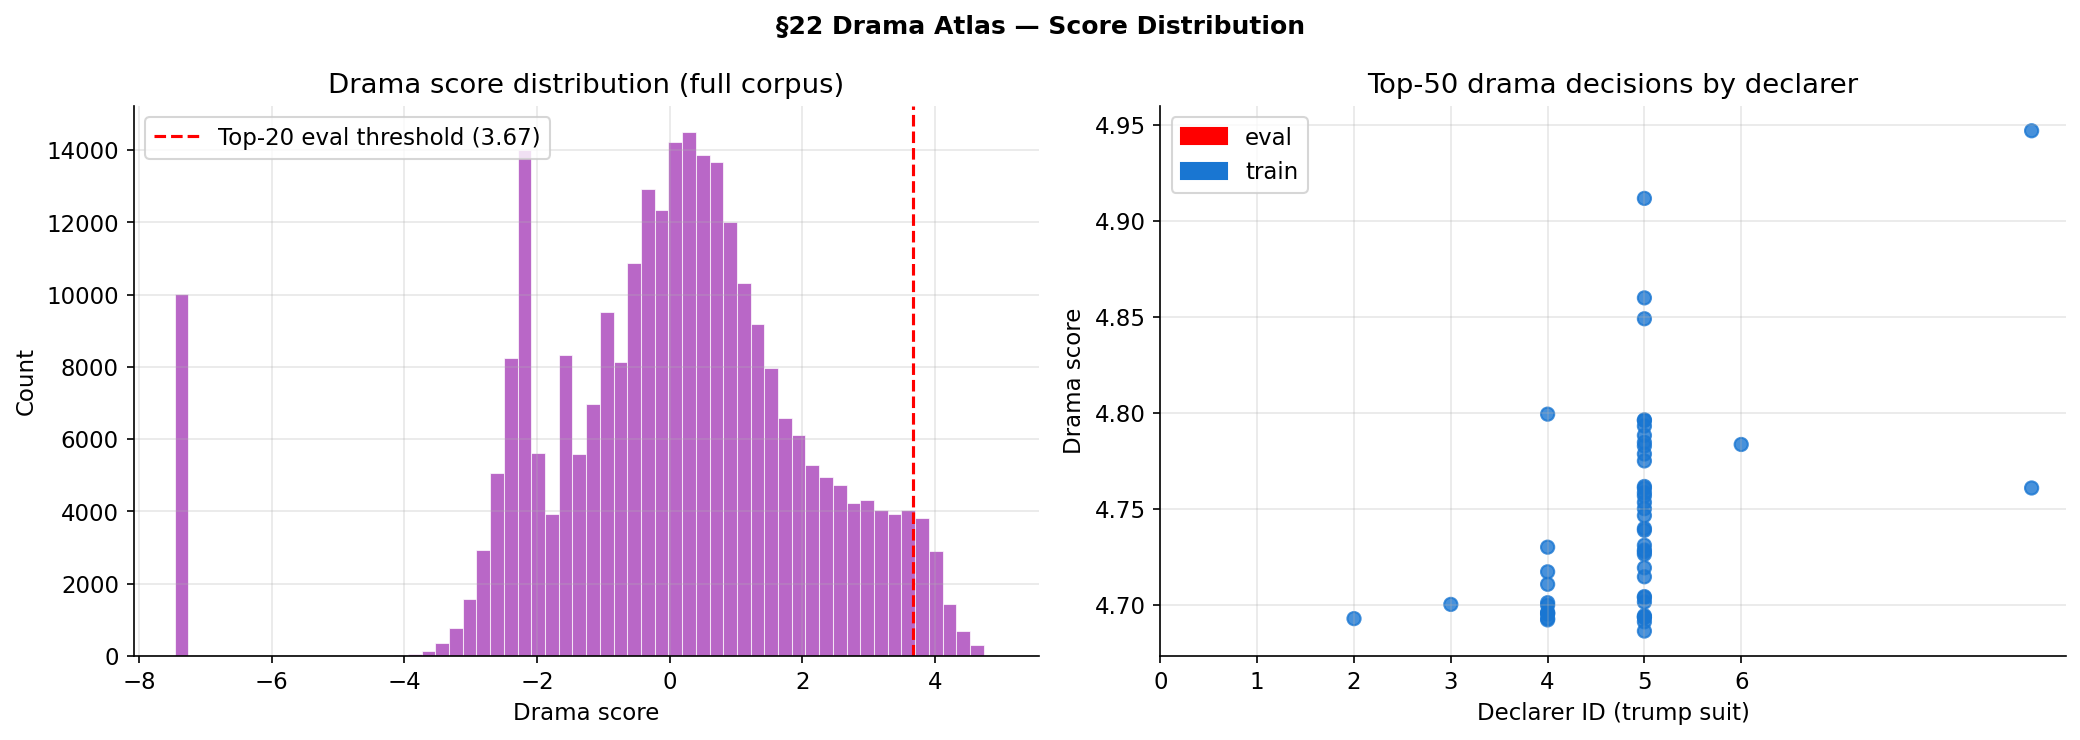

Saved: figures/drama_score_distribution.png


In [14]:
# Drama score distribution and top-20 visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['drama_score'], bins=60, color='#9C27B0', alpha=0.7, edgecolor='white', linewidth=0.5)
threshold_top20 = top_drama['drama_score'].min()
ax.axvline(threshold_top20, color='red', linestyle='--', linewidth=1.5,
           label=f'Top-20 eval threshold ({threshold_top20:.2f})')
ax.set_xlabel('Drama score')
ax.set_ylabel('Count')
ax.set_title('Drama score distribution (full corpus)')
ax.legend()

ax = axes[1]
# Scatter drama_score vs decl_id for top drama decisions from both splits
top_all = df.nlargest(50, 'drama_score')
colors_split = ['red' if s == 'eval' else '#1976D2' for s in top_all['split']]
ax.scatter(top_all['decl_id'], top_all['drama_score'],
           c=colors_split, s=40, alpha=0.8)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='red', label='eval'), Patch(color='#1976D2', label='train')])
ax.set_xlabel('Declarer ID (trump suit)')
ax.set_ylabel('Drama score')
ax.set_title('Top-50 drama decisions by declarer')
ax.set_xticks(range(7))

fig.suptitle('§22 Drama Atlas — Score Distribution', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'drama_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/drama_score_distribution.png')

## 7. Deep Dive: Top Drama Decisions

In [15]:
# Per-decision world distribution for the top 5 drama decisions (eval)
print('=== Top 5 drama decisions — world distribution detail ===')
for _, row in top_drama.head(5).iterrows():
    dist = json.loads(row['per_world_top_action_distribution'])
    total_worlds = sum(dist.values())
    print(f"\nSeed {row['seed']}, d_idx={row['d_idx']}, player={row['current_player']}, decl={row['decl_id']}")
    print(f"  Drama score: {row['drama_score']:.3f}")
    print(f"  Fragility: {row['action_fragility']} distinct oracle choices")
    print(f"  Outcome variance: {row['outcome_variance']:.3f} Q-pts")
    print(f"  Belief sharpness: {row['belief_sharpness']:.4f}")
    print(f"  Oracle worlds per action: ", end='')
    for a, cnt in sorted(dist.items(), key=lambda x: -x[1]):
        print(f"  action_{a}: {cnt}/{total_worlds} ({100*cnt/total_worlds:.0f}%)", end='')
    print()
    print(f"  Gus chose: action_{int(row['gus_pi_action'])} | Oracle mode: action_{int(row['mode_action'])} | Taken: action_{int(row['action_taken'])}")
    print(f"  Gus matches oracle mode: {bool(row['gus_matches_mode'])}")
    print(f"  e_q_taken={row['e_q_taken']:.2f}, e_q_max={row['e_q_max']:.2f}")

=== Top 5 drama decisions — world distribution detail ===

Seed 900016, d_idx=0, player=0, decl=6
  Drama score: 4.378
  Fragility: 7 distinct oracle choices
  Outcome variance: 27.902 Q-pts
  Belief sharpness: 0.0068
  Oracle worlds per action:   action_0: 1321/4000 (33%)  action_1: 980/4000 (24%)  action_6: 645/4000 (16%)  action_3: 502/4000 (13%)  action_2: 425/4000 (11%)  action_4: 108/4000 (3%)  action_5: 19/4000 (0%)
  Gus chose: action_0 | Oracle mode: action_0 | Taken: action_6
  Gus matches oracle mode: True
  e_q_taken=-10.76, e_q_max=-6.43

Seed 900013, d_idx=0, player=0, decl=3
  Drama score: 4.331
  Fragility: 7 distinct oracle choices
  Outcome variance: 27.433 Q-pts
  Belief sharpness: 0.0057
  Oracle worlds per action:   action_4: 1848/4000 (46%)  action_1: 710/4000 (18%)  action_2: 655/4000 (16%)  action_6: 641/4000 (16%)  action_3: 66/4000 (2%)  action_0: 56/4000 (1%)  action_5: 24/4000 (1%)
  Gus chose: action_1 | Oracle mode: action_4 | Taken: action_4
  Gus matches

In [16]:
# Summary statistics for each quadrant — deeper analysis
print('=== Extended quadrant analysis ===')
quadrant_deep = df.groupby('quadrant').agg(
    n=('d_idx', 'count'),
    frac_of_corpus=('d_idx', lambda x: len(x) / len(df)),
    mean_drama_score=('drama_score', 'mean'),
    p95_outcome_var=('outcome_variance', lambda x: x.quantile(0.95)),
    mean_fragility=('action_fragility', 'mean'),
    mean_sharpness=('belief_sharpness', 'mean'),
    gus_mode_agreement=('gus_matches_mode', 'mean'),
    mean_p_make=('p_make_taken', 'mean'),
    early_game_frac=('d_idx', lambda x: (x < 12).mean()),
    late_game_frac=('d_idx', lambda x: (x >= 20).mean()),
).round(4)
print(quadrant_deep.to_string())
quadrant_deep.to_csv(TABLES_DIR / 'quadrant_deep_analysis.csv')
print('\nSaved: tables/quadrant_deep_analysis.csv')

=== Extended quadrant analysis ===


                       n  frac_of_corpus  mean_drama_score  p95_outcome_var  mean_fragility  mean_sharpness  gus_mode_agreement  mean_p_make  early_game_frac  late_game_frac
quadrant                                                                                                                                                                     
drama              73557          0.2622            2.1055          27.2995          4.8778          0.0119              0.5259       0.5251           0.6443          0.0000
easy-high-stakes   34121          0.1216            1.0538          25.5831          3.9627          0.0304              0.4652       0.5361           0.3969          0.0000
easy-robust       106155          0.3784           -1.7625          23.4614          1.2861          0.1419              0.8655       0.4982           0.1807          0.6277
foggy-forced       66727          0.2378           -0.0557          26.4735          1.4402          0.0138              0.8502   

In [17]:
# Final headline numbers for the findings doc
print('=== HEADLINE NUMBERS FOR FINDINGS DOC ===')
print(f'Total decisions: {len(df):,}')
print(f'  Train: {(df["split"]=="train").sum():,}')
print(f'  Eval: {(df["split"]=="eval").sum():,}')
print()

for q in ['easy-robust', 'foggy-forced', 'easy-high-stakes', 'drama']:
    n = (df['quadrant'] == q).sum()
    frac = n / len(df)
    print(f'  {q}: {n:,} ({frac:.1%})')

print()
drama = df[df['quadrant'] == 'drama']
non_drama = df[df['quadrant'] != 'drama']
print(f'Drama decisions: {len(drama):,} ({len(drama)/len(df):.1%})')
print(f'Gus-mode agreement overall: {df["gus_matches_mode"].mean():.3%}')
print(f'Gus-mode agreement on drama: {drama["gus_matches_mode"].mean():.3%}')
print(f'Gus-mode agreement on easy-robust: {df.loc[df["quadrant"]=="easy-robust", "gus_matches_mode"].mean():.3%}')
print()
print(f'Drama by trick position:')
for pos, label in [(0, 'Lead'), (1, '2nd'), (2, '3rd'), (3, '4th')]:
    pos_data = df[df['trick_pos'] == pos]
    drama_frac = (pos_data['quadrant'] == 'drama').mean()
    print(f'  {label}: {drama_frac:.1%}')
print()
print(f'Drama by game phase:')
for name, mask in [('Early (d_idx 0-11)', df['d_idx'] < 12),
                    ('Mid (d_idx 12-19)', (df['d_idx'] >= 12) & (df['d_idx'] < 20)),
                    ('Late (d_idx 20-27)', df['d_idx'] >= 20)]:
    sub = df[mask]
    drama_frac = (sub['quadrant'] == 'drama').mean()
    print(f'  {name}: {drama_frac:.1%}')

=== HEADLINE NUMBERS FOR FINDINGS DOC ===
Total decisions: 280,560
  Train: 280,000
  Eval: 560

  easy-robust: 106,155 (37.8%)
  foggy-forced: 66,727 (23.8%)
  easy-high-stakes: 34,121 (12.2%)
  drama: 73,557 (26.2%)

Drama decisions: 73,557 (26.2%)
Gus-mode agreement overall: 72.413%
Gus-mode agreement on drama: 52.593%
Gus-mode agreement on easy-robust: 86.545%

Drama by trick position:
  Lead: 64.9%
  2nd: 14.6%
  3rd: 12.7%
  4th: 12.7%

Drama by game phase:
  Early (d_idx 0-11): 39.4%
  Mid (d_idx 12-19): 32.6%
  Late (d_idx 20-27): 0.0%


## 8. Save Final Atlas with Drama Score + Quadrant Labels

In [18]:
# Re-save parquet with quadrant + drama_score columns added
df.to_parquet(ATLAS_PATH, index=False)
print(f'Atlas saved with {len(df.columns)} columns, {len(df):,} rows')
print('Columns:', list(df.columns))

Atlas saved with 22 columns, 280,560 rows
Columns: ['split', 'seed', 'game_idx', 'd_idx', 'current_player', 'decl_id', 'outcome_variance', 'action_fragility', 'belief_sharpness', 'p_make_taken', 'mode_action', 'gus_pi_action', 'gus_matches_mode', 'action_taken', 'n_legal_actions', 'e_q_taken', 'e_q_max', 'per_world_top_action_distribution', 'quadrant', 'drama_score', 'trick_num', 'trick_pos']
